In [37]:
import pandas as pd
import math
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import statistics

import matplotlib.pyplot as plt

In [38]:
df = pd.read_csv("cabai hijau.csv", sep=";")
df

,Komoditas (Rp),Semua Provinsi,Jawa Timur
0,Apr 2017 (I),40259,29200
1,Apr 2017 (II),39954,29750
2,Apr 2017 (III),37914,30350
3,Apr 2017 (IV),35500,30100
4,May 2017 (V),36431,28550
...,...,...,...
302,Jan 2023 (IV),40269,29900
303,Feb 2023 (I),40657,31450
304,Feb 2023 (II),42054,32450
305,Feb 2023 (III),43128,33250


In [39]:
df_copy = df.copy()

last = len(df_copy.index)
nPred = 15

df_copy = df_copy.drop(index=df.index[last-nPred:last])

df_copy.reset_index(inplace=True, drop=True)
df_copy

,Komoditas (Rp),Semua Provinsi,Jawa Timur
0,Apr 2017 (I),40259,29200
1,Apr 2017 (II),39954,29750
2,Apr 2017 (III),37914,30350
3,Apr 2017 (IV),35500,30100
4,May 2017 (V),36431,28550
...,...,...,...
287,Oct 2022 (III),36163,17800
288,Oct 2022 (IV),34346,17000
289,Oct 2022 (V),33531,15650
290,Nov 2022 (I),32884,15700


In [40]:
df_copy

,Komoditas (Rp),Semua Provinsi,Jawa Timur
0,Apr 2017 (I),40259,29200
1,Apr 2017 (II),39954,29750
2,Apr 2017 (III),37914,30350
3,Apr 2017 (IV),35500,30100
4,May 2017 (V),36431,28550
...,...,...,...
287,Oct 2022 (III),36163,17800
288,Oct 2022 (IV),34346,17000
289,Oct 2022 (V),33531,15650
290,Nov 2022 (I),32884,15700


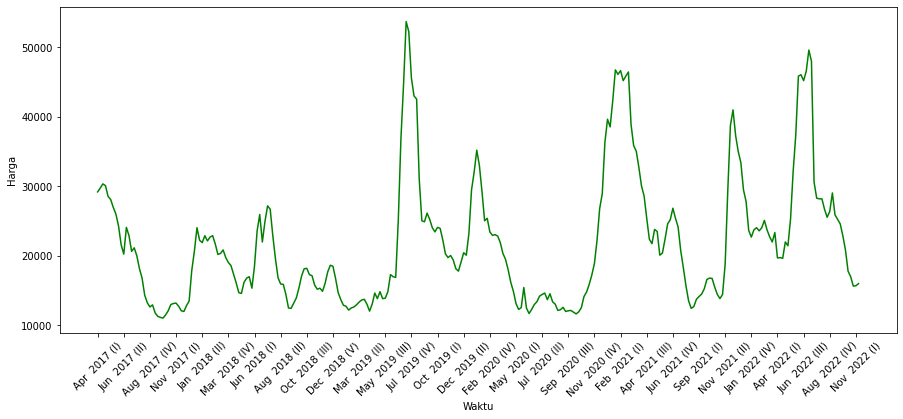

In [41]:
plt.figure(figsize=(15,6))
plt.plot(df_copy['Komoditas (Rp)'], df_copy['Jawa Timur'], color='green')
plt.xlabel('Waktu')
plt.ylabel('Harga')
plt.xticks(rotation=45)
plt.xticks(np.arange(0,len(df_copy.index)-1,10))
plt.show()

In [42]:
sd = statistics.pstdev(df_copy['Jawa Timur'].to_numpy())
meanS = statistics.mean(df_copy['Jawa Timur'].to_numpy())
print("Koefisien Variasi = ",sd/meanS*100,"%")

Koefisien Variasi =  42.14493051586686 %


In [43]:
Dt = df_copy['Jawa Timur']
Dmin = Dt.min()
Dmax = Dt.max()
N = Dt.count()
Z1 = 950
Z2 = 400

print(Dmin, Dmax, N)

11050 53700 292


In [44]:
R = Dmax+Z2 - (Dmin-Z1)
print(R)

44000


In [45]:
dif = []
df2 = df_copy

for i in range (N-1):
    dt = df['Jawa Timur'][i]
    dt2 = df['Jawa Timur'][i+1]
    ab = round(abs(dt2-dt),2)
    df2.at[i, '|Dt+1 - Dt|'] = ab

df2.at[N-1, '|Dt+1 - Dt|'] = 0

In [46]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|
0,Apr 2017 (I),40259,29200,550.0
1,Apr 2017 (II),39954,29750,600.0
2,Apr 2017 (III),37914,30350,250.0
3,Apr 2017 (IV),35500,30100,1550.0
4,May 2017 (V),36431,28550,450.0
...,...,...,...,...
287,Oct 2022 (III),36163,17800,800.0
288,Oct 2022 (IV),34346,17000,1350.0
289,Oct 2022 (V),33531,15650,50.0
290,Nov 2022 (I),32884,15700,300.0


In [47]:
mean = (sum(df2['|Dt+1 - Dt|']))/(N-1)
print(mean)

1704.1237113402062


In [48]:
K = mean/2
if(K<1):
    K = round(K,1)
else:
    K = math.ceil(K)

print(K)

853


In [49]:
n = math.ceil(R/K)
print(n)

52


In [50]:
himpFuzzy = pd.DataFrame()
ui = []
batasBawah = []
batasAtas = []
Ai = []
ui.append('u1')
Ai.append('A1')
batasBawah.append(Dmin-Z1)
batasAtas.append(batasBawah[0] + K)

for i in range(1, n):
    ui.append('u'+str(i+1))
    Ai.append('A'+str(i+1))
    batasBawah.append(batasAtas[i-1])
    batasAtas.append(batasBawah[i] + K)

himpFuzzy['ui'] = ui
himpFuzzy['Ai'] = Ai
himpFuzzy['batas bawah'] = batasBawah
himpFuzzy['batas atas'] = batasAtas

In [51]:
himpFuzzy['mi'] = (himpFuzzy['batas bawah'] + himpFuzzy['batas atas'])/2

In [52]:
himpFuzzy

,ui,Ai,batas bawah,batas atas,mi
0,u1,A1,10100,10953,10526.5
1,u2,A2,10953,11806,11379.5
2,u3,A3,11806,12659,12232.5
3,u4,A4,12659,13512,13085.5
4,u5,A5,13512,14365,13938.5
5,u6,A6,14365,15218,14791.5
6,u7,A7,15218,16071,15644.5
7,u8,A8,16071,16924,16497.5
8,u9,A9,16924,17777,17350.5
9,u10,A10,17777,18630,18203.5


In [53]:
# FLR dan FLRG
data = df2['Jawa Timur']

hasilFuzzy = []
for i in data:
    copyHimp = himpFuzzy
    cond1 = copyHimp['batas bawah'] <= i 
    cond2 = copyHimp['batas atas'] >= i 
    dfAi = copyHimp.where(cond1 & cond2) 
    dfAi = dfAi[~dfAi['ui'].isna()]
    fuzzyfikasi = dfAi['Ai'].iloc[0]
    hasilFuzzy.append(fuzzyfikasi)

df2['fuzzyfikasi'] = hasilFuzzy

In [54]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi
0,Apr 2017 (I),40259,29200,550.0,A23
1,Apr 2017 (II),39954,29750,600.0,A24
2,Apr 2017 (III),37914,30350,250.0,A24
3,Apr 2017 (IV),35500,30100,1550.0,A24
4,May 2017 (V),36431,28550,450.0,A22
...,...,...,...,...,...
287,Oct 2022 (III),36163,17800,800.0,A10
288,Oct 2022 (IV),34346,17000,1350.0,A9
289,Oct 2022 (V),33531,15650,50.0,A7
290,Nov 2022 (I),32884,15700,300.0,A7


In [55]:
nextState = []
for k in range(0, len(df2.index)-1):
    neSt = df2['fuzzyfikasi'].iloc[k+1]
    nextState.append(neSt)

df2['next state'] = pd.Series(nextState)

In [56]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state
0,Apr 2017 (I),40259,29200,550.0,A23,A24
1,Apr 2017 (II),39954,29750,600.0,A24,A24
2,Apr 2017 (III),37914,30350,250.0,A24,A24
3,Apr 2017 (IV),35500,30100,1550.0,A24,A22
4,May 2017 (V),36431,28550,450.0,A22,A22
...,...,...,...,...,...,...
287,Oct 2022 (III),36163,17800,800.0,A10,A9
288,Oct 2022 (IV),34346,17000,1350.0,A9,A7
289,Oct 2022 (V),33531,15650,50.0,A7,A7
290,Nov 2022 (I),32884,15700,300.0,A7,A7


In [57]:
# FLRG
dfFLRG = pd.DataFrame()
dfFLRG['Ai'] = himpFuzzy['Ai']
dfFLRG['FLRG'] = ''

# ambil df2 kecuali baris terakhir karena next statenya kosong
df3 = df2[:-1]

for f in range(len(dfFLRG.index)):
    searchAi = 'A'+str(f+1)
    
    new = df3[df3['fuzzyfikasi'].isin([searchAi])]
    group = new['next state']
    group = group.to_numpy()
    
    if len(group) > 0 :
        dfFLRG['FLRG'][f] = group

In [58]:
dfFLRG

,Ai,FLRG
0,A1,
1,A2,"[A2, A2, A2, A2, A3, A3, A3]"
2,A3,"[A4, A4, A3, A4, A3, A4, A3, A3, A4, A4, A3, A..."
3,A4,"[A3, A2, A4, A4, A4, A3, A4, A10, A5, A4, A3, ..."
4,A5,"[A4, A7, A4, A5, A4, A6, A5, A6, A6, A6, A6, A..."
5,A6,"[A6, A8, A3, A7, A7, A5, A5, A5, A9, A4, A6, A..."
6,A7,"[A10, A7, A6, A9, A6, A6, A9, A3, A9, A5, A8, ..."
7,A8,"[A5, A6, A8, A9, A7, A6, A18, A6, A8, A8, A7]"
8,A9,"[A8, A7, A10, A9, A7, A11, A9, A8, A11, A7]"
9,A10,"[A8, A13, A9, A16, A10, A9, A8, A10, A11, A8, ..."


In [59]:
# hasil fuzzyfikasi
dfFLRG['defuzzyfikasi'] = ''

for g in range(len(dfFLRG.index)):
    ai = dfFLRG['Ai'].loc[g]
    flrg = dfFLRG['FLRG'].loc[g]
    hasil = 0

    if (len(flrg) == 0):
        fuzzyfikasi = himpFuzzy[himpFuzzy['Ai'] == ai]['mi']
        hasil = fuzzyfikasi.values[0]
    
    elif (len(flrg) == 1):
        fuzzyfikasi = himpFuzzy[himpFuzzy['Ai'] == flrg[0]]['mi']
        hasil = fuzzyfikasi.values[0]
        
    else:
        lenFlrg = len(flrg)
        for h in range(len(flrg)):
            mi = himpFuzzy[himpFuzzy['Ai'] == flrg[h]]['mi']
            bobot = (1/len(flrg)) * mi.values[0]
            hasil = hasil + bobot
            

    dfFLRG['defuzzyfikasi'][g] = hasil

In [60]:
dfFLRG

,Ai,FLRG,defuzzyfikasi
0,A1,,10526.5
1,A2,"[A2, A2, A2, A2, A3, A3, A3]",11745.071429
2,A3,"[A4, A4, A3, A4, A3, A4, A3, A3, A4, A4, A3, A...",12659.0
3,A4,"[A3, A2, A4, A4, A4, A3, A4, A10, A5, A4, A3, ...",13247.97619
4,A5,"[A4, A7, A4, A5, A4, A6, A5, A6, A6, A6, A6, A...",14165.966667
5,A6,"[A6, A8, A3, A7, A7, A5, A5, A5, A9, A4, A6, A...",14891.852941
6,A7,"[A10, A7, A6, A9, A6, A6, A9, A3, A9, A5, A8, ...",15644.5
7,A8,"[A5, A6, A8, A9, A7, A6, A18, A6, A8, A8, A7]",16497.5
8,A9,"[A8, A7, A10, A9, A7, A11, A9, A8, A11, A7]",17094.6
9,A10,"[A8, A13, A9, A16, A10, A9, A8, A10, A11, A8, ...",18061.333333


In [61]:
df2['yt'] = ''

for y in range (len(dfFLRG.index)):
    ai = dfFLRG['Ai'].loc[y]
    listAi = df2[df2['fuzzyfikasi'] == ai]
    yt = dfFLRG['defuzzyfikasi'][y]
    
    if len(listAi) > 0:
        idx = listAi.index
        for z in idx:
            df2.at[z+1,'yt'] = yt

In [62]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state,yt
0,Apr 2017 (I),40259.0,29200.0,550.0,A23,A24,
1,Apr 2017 (II),39954.0,29750.0,600.0,A24,A24,30754.785714
2,Apr 2017 (III),37914.0,30350.0,250.0,A24,A24,29292.5
3,Apr 2017 (IV),35500.0,30100.0,1550.0,A24,A22,29292.5
4,May 2017 (V),36431.0,28550.0,450.0,A22,A22,29292.5
...,...,...,...,...,...,...,...
288,Oct 2022 (IV),34346.0,17000.0,1350.0,A9,A7,18061.333333
289,Oct 2022 (V),33531.0,15650.0,50.0,A7,A7,17094.6
290,Nov 2022 (I),32884.0,15700.0,300.0,A7,A7,15644.5
291,Nov 2022 (II),32666.0,16000.0,0.0,A7,NaN,15644.5


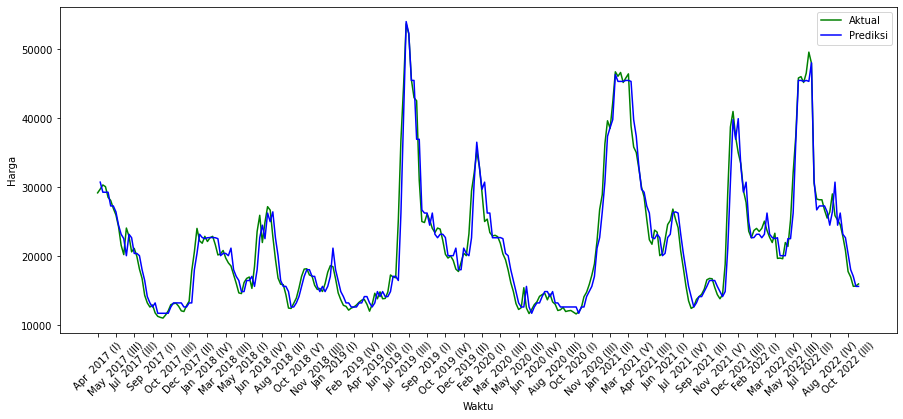

In [63]:
df2_copy = df2.copy()
df2_copy = df2_copy.drop(index=df2_copy.index[-1])
df2_copy.reset_index(inplace=True, drop=True)
df2_copy
plt.figure(figsize=(15,6))
plt.plot(df2_copy['Komoditas (Rp)'], df2_copy['Jawa Timur'], color='green', label='Aktual')
plt.plot(df2_copy['Komoditas (Rp)'][1:], df2_copy['yt'][1:], color='blue', label='Prediksi')
plt.xlabel('Waktu')
plt.ylabel('Harga')
plt.xticks(rotation=45)
plt.xticks(np.arange(0,len(df2_copy.index),7))
plt.legend()
plt.show()

In [64]:
# MAPE
y_actual = df2['Jawa Timur'][1:-1].to_numpy()
y_predict = df2['yt'][1:-1].to_numpy()

# MAE
MAE = mean_absolute_error(y_actual, y_predict)
print("MAE = ",MAE)

# Root MSE squared=False
RMSE = mean_squared_error(y_actual, y_predict, squared=False)
print("RMSE = ",RMSE)

MAPE = mean_absolute_percentage_error(y_actual, y_predict)
print("MAPE = ",MAPE*100)

MAE =  1408.2032227570733
RMSE =  2102.4305521477722
MAPE =  6.55694881090876


In [65]:
lastIndex = len(df2.index)
dfPredictNext = df2

for n in range (nPred-1):
    # Add fuzzyfikai dr hasil predict
    nilaiYt = dfPredictNext['yt'][lastIndex-1+n]
    
    copyHimp = himpFuzzy
    cond1 = copyHimp['batas bawah'] <= nilaiYt
    cond2 = copyHimp['batas atas'] >= nilaiYt
    dfAi = copyHimp.where(cond1 & cond2) 
    dfAi = dfAi[~dfAi['ui'].isna()]
    fuzzyfikasi = dfAi['Ai'].iloc[0]
    dfPredictNext.at[lastIndex + n-1, 'fuzzyfikasi'] = fuzzyfikasi

    # add predict
    yt = dfFLRG['defuzzyfikasi'][dfFLRG['Ai'] == fuzzyfikasi]
    dfPredictNext.at[lastIndex+n, 'yt'] = yt.values[0]    

In [66]:
dfPredictNext

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state,yt
0,Apr 2017 (I),40259.0,29200.0,550.0,A23,A24,
1,Apr 2017 (II),39954.0,29750.0,600.0,A24,A24,30754.785714
2,Apr 2017 (III),37914.0,30350.0,250.0,A24,A24,29292.5
3,Apr 2017 (IV),35500.0,30100.0,1550.0,A24,A22,29292.5
4,May 2017 (V),36431.0,28550.0,450.0,A22,A22,29292.5
...,...,...,...,...,...,...,...
302,NaN,NaN,NaN,NaN,A7,NaN,15644.5
303,NaN,NaN,NaN,NaN,A7,NaN,15644.5
304,NaN,NaN,NaN,NaN,A7,NaN,15644.5
305,NaN,NaN,NaN,NaN,A7,NaN,15644.5


In [67]:
dfPredictNext[len(dfPredictNext.index)-nPred:]

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state,yt
292,NaN,NaN,NaN,NaN,A7,NaN,15644.5
293,NaN,NaN,NaN,NaN,A7,NaN,15644.5
294,NaN,NaN,NaN,NaN,A7,NaN,15644.5
295,NaN,NaN,NaN,NaN,A7,NaN,15644.5
296,NaN,NaN,NaN,NaN,A7,NaN,15644.5
297,NaN,NaN,NaN,NaN,A7,NaN,15644.5
298,NaN,NaN,NaN,NaN,A7,NaN,15644.5
299,NaN,NaN,NaN,NaN,A7,NaN,15644.5
300,NaN,NaN,NaN,NaN,A7,NaN,15644.5
301,NaN,NaN,NaN,NaN,A7,NaN,15644.5


In [68]:
df_result = df.copy()
df_result['yt'] = df2['yt']
df_result

,Komoditas (Rp),Semua Provinsi,Jawa Timur,yt
0,Apr 2017 (I),40259,29200,
1,Apr 2017 (II),39954,29750,30754.785714
2,Apr 2017 (III),37914,30350,29292.5
3,Apr 2017 (IV),35500,30100,29292.5
4,May 2017 (V),36431,28550,29292.5
...,...,...,...,...
302,Jan 2023 (IV),40269,29900,15644.5
303,Feb 2023 (I),40657,31450,15644.5
304,Feb 2023 (II),42054,32450,15644.5
305,Feb 2023 (III),43128,33250,15644.5


In [69]:
df_result[len(df_result.index)-nPred:]

,Komoditas (Rp),Semua Provinsi,Jawa Timur,yt
292,Nov 2022 (III),33087,16350,15644.5
293,Nov 2022 (IV),34378,20500,15644.5
294,Dec 2022 (I),38299,28050,15644.5
295,Dec 2022 (II),40853,28000,15644.5
296,Dec 2022 (III),43779,28050,15644.5
297,Dec 2022 (IV),44675,29350,15644.5
298,Jan 2023 (V),48894,38750,15644.5
299,Jan 2023 (I),46625,38500,15644.5
300,Jan 2023 (II),43897,35200,15644.5
301,Jan 2023 (III),41996,31800,15644.5


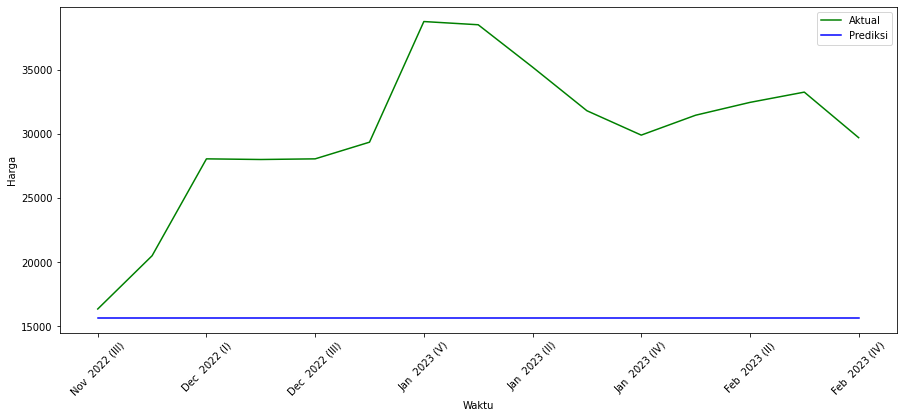

In [70]:
plt.figure(figsize=(15,6))
plt.plot(df_result['Komoditas (Rp)'][len(df_result.index)-nPred:], df_result['Jawa Timur'][len(df_result.index)-nPred:], color='green', label='Aktual')
plt.plot(df_result['Komoditas (Rp)'][len(df_result.index)-nPred:], df_result['yt'][len(df_result.index)-nPred:], color='blue', label='Prediksi')
plt.xlabel('Waktu')
plt.ylabel('Harga')
plt.xticks(rotation=45)
plt.xticks(np.arange(0,nPred,2))
plt.legend()
plt.show()

In [71]:
# MAPE pred
y_actualpred = df_result['Jawa Timur'][last-nPred:len(df_result.index)].to_numpy()
y_predictpred = df_result['yt'][last-nPred:len(df_result.index)].to_numpy()

# MAPE
MAPE2 = mean_absolute_percentage_error(y_actualpred, y_predictpred)
# Root MSE squared=False
RMSE2 = mean_squared_error(y_actualpred, y_predictpred, squared=False)
# MAE
MAE2 = mean_absolute_error(y_actualpred, y_predictpred)

print("Hasil MAPE untuk memprediksi data",nPred,"periode kedepan")
print("MAE = ",MAE2)
print("RMSE = ",RMSE2)
print("MAPE = ",MAPE2*100)

Hasil MAPE untuk memprediksi data 15 periode kedepan
MAE =  14442.166666666668
RMSE =  15524.153232409599
MAPE =  45.508230964886145


In [72]:
# MAPE all
y_actual2 = df_result['Jawa Timur'][1:len(df_result.index)].to_numpy()
# print(y_actual2)
y_predict2 = df_result['yt'][1:len(df_result.index)].to_numpy()
# MAPE
MAPE3 = mean_absolute_percentage_error(y_actual2, y_predict2)
# Root MSE squared=False
RMSE3 = mean_squared_error(y_actual2, y_predict2, squared=False)
# MAE
MAE3 = mean_absolute_error(y_actual2, y_predict2)
print("MAE = ",MAE3)
print("RMSE = ",RMSE3)
print("MAPE = ",MAPE3*100)

MAE =  2047.1229994193084
RMSE =  4002.15315565834
MAPE =  8.46632538708412
